# Akademik Yanılgı: Rastgele Tohum Piyangosu (Random Seed Lottery)
Bu çalışmanın amacı, makine öğrenmesi literatüründe sıkça karşılaşılan bir hatayı deşifre etmektir. Veri setindeki en büyük 2 yangının (1090 ha ve 746 ha) eğitim veya test setine düşmesinin, modelin (SVM-RBF) başarımını nasıl tamamen değiştirdiğini simüle edeceğiz.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [4]:
# 1. Temizlenmiş özellikleri alıyoruz
df = pd.read_csv("../../data/processed/processed_forestfires_v2.csv")

# 2. Hiçbir Tweedie/Log karmaşasına girmemek için doğrudan HAM VERİ'den alanı çekiyoruz
df_raw = pd.read_csv("../../data/raw/forestfires.csv")
df['area'] = df_raw['area'] # Orijinal hektarları güvenle geri koyduk

# En büyük 2 yangını tespit edelim
top2_fires = df.nlargest(2, 'area')
fire_1 = top2_fires.iloc[[0]] 
fire_2 = top2_fires.iloc[[1]] 

# Bu 2 devasa yangını ana veri setinden çıkaralım (Geriye 515 satır kalacak)
df_remainder = df.drop(top2_fires.index)

print("1. En Büyük Yangın Alanı (Ham Hektar):", fire_1['area'].values[0])
print("2. En Büyük Yangın Alanı (Ham Hektar):", fire_2['area'].values[0])
print("Kalan Veri Boyutu:", df_remainder.shape)

1. En Büyük Yangın Alanı (Ham Hektar): 1090.84
2. En Büyük Yangın Alanı (Ham Hektar): 746.28
Kalan Veri Boyutu: (515, 23)


In [5]:
# Geri kalan 515 satırı standart şekilde ayırıyoruz (%80 Train, %20 Test)
# random_state=42 sabittir, yani bu 515 satır hep aynı şekilde dağılır.
X_rem = df_remainder.drop(columns=['area'])
y_rem = df_remainder['area']

X_tr_base, X_te_base, y_tr_base, y_te_base = train_test_split(X_rem, y_rem, test_size=0.20, random_state=42)

# Senaryoları hazırlayan yardımcı fonksiyon
def create_scenario(train_add, test_add):
    X_tr = pd.concat([X_tr_base] + ([add.drop(columns=['area']) for add in train_add] if train_add else []))
    y_tr = pd.concat([y_tr_base] + ([add['area'] for add in train_add] if train_add else []))
    X_te = pd.concat([X_te_base] + ([add.drop(columns=['area']) for add in test_add] if test_add else []))
    y_te = pd.concat([y_te_base] + ([add['area'] for add in test_add] if test_add else []))
    return X_tr, X_te, y_tr, y_te

# Senaryo A: İki dev yangın da TEST'te (Felaket Senaryosu - Outliers in Test)
sA = create_scenario(train_add=[], test_add=[fire_1, fire_2])

# Senaryo B: Yangın-1 TEST'te, Yangın-2 TRAIN'de
sB = create_scenario(train_add=[fire_2], test_add=[fire_1])

# Senaryo C: Yangın-1 TRAIN'de, Yangın-2 TEST'te
sC = create_scenario(train_add=[fire_1], test_add=[fire_2])

# Senaryo D: İki dev yangın da TRAIN'de (Yalancı Akademik Başarı - Outliers in Train)
sD = create_scenario(train_add=[fire_1, fire_2], test_add=[])

scenarios = {"Senaryo A (İkisi de TEST)": sA, 
             "Senaryo B (Y1:TEST, Y2:TRAIN)": sB, 
             "Senaryo C (Y1:TRAIN, Y2:TEST)": sC, 
             "Senaryo D (İkisi de TRAIN)": sD}

In [6]:
results = []

for name, (X_train, X_test, y_train, y_test) in scenarios.items():
    # Özellikleri (X) ölçeklendir
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    # Hedef değişkeni (y) ölçeklendir (SVM'in 1000 gibi devasa sayılarda zorlanmaması için)
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    
    # Standart SVM modeli
    model = SVR(kernel='rbf', C=100, gamma='scale')
    model.fit(X_train_scaled, y_train_scaled)
    
    # Tahmin yap ve sonuçları tekrar orijinal ham hektar formatına geri büyüt (Inverse Transform)
    preds_scaled = model.predict(X_test_scaled)
    preds_original = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
    
    # Alan eksi olamaz, negatif tahminleri sıfıra yuvarla
    preds_original = np.clip(preds_original, 0, None) 
    
    # MAE ve RMSE'yi doğrudan ham hektarlar üzerinden hesapla!
    mae = mean_absolute_error(y_test, preds_original)
    rmse = np.sqrt(mean_squared_error(y_test, preds_original))
    
    results.append({"Senaryo": name, "MAE": mae, "RMSE": rmse})

df_results = pd.DataFrame(results)
display(df_results)

,Senaryo,MAE,RMSE
0,Senaryo A (İkisi de TEST),34.044452,133.290599
1,"Senaryo B (Y1:TEST, Y2:TRAIN)",28.200918,112.727686
2,"Senaryo C (Y1:TRAIN, Y2:TEST)",23.905089,81.071088
3,Senaryo D (İkisi de TRAIN),18.766281,39.215944


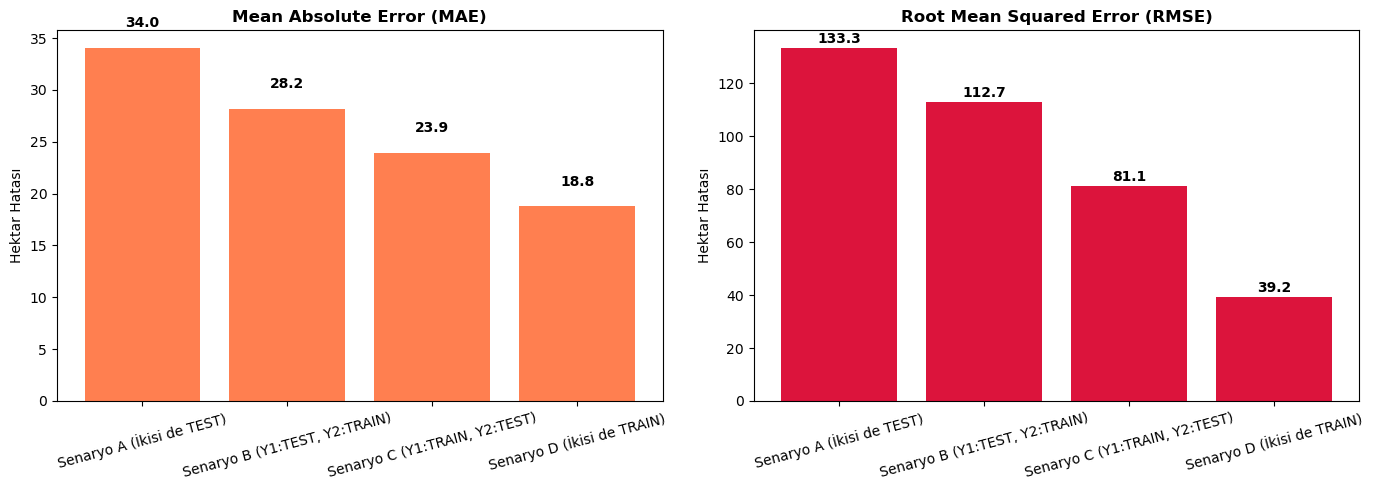

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# MAE Grafiği
ax[0].bar(df_results['Senaryo'], df_results['MAE'], color='coral')
ax[0].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Hektar Hatası')
ax[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(df_results['MAE']):
    ax[0].text(i, v + 2, f"{v:.1f}", ha='center', fontweight='bold')

# RMSE Grafiği
ax[1].bar(df_results['Senaryo'], df_results['RMSE'], color='crimson')
ax[1].set_title('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Hektar Hatası')
ax[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(df_results['RMSE']):
    ax[1].text(i, v + 2, f"{v:.1f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()